In [12]:
import pandas as pd
import numpy as nm
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("Mall_Customers.csv")

In [3]:
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
data = data.drop('CustomerID', axis = 1)

In [5]:
def LabelEnc(x):
    if (x == "Male"):
        return 0
    else:
        return 1
    
data["Genre"] = data["Genre"].apply(LabelEnc)

In [6]:
x = data.iloc[:, -2: ]
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [13]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [14]:
wcss = []
silScore = []

for k in range (2, 15):
        km = KMeans(n_clusters=k)
        prediction = km.fit_predict(x)
        
        score = silhouette_score(x, prediction)
        wcss.append(km.inertia_)
        silScore.append(score)

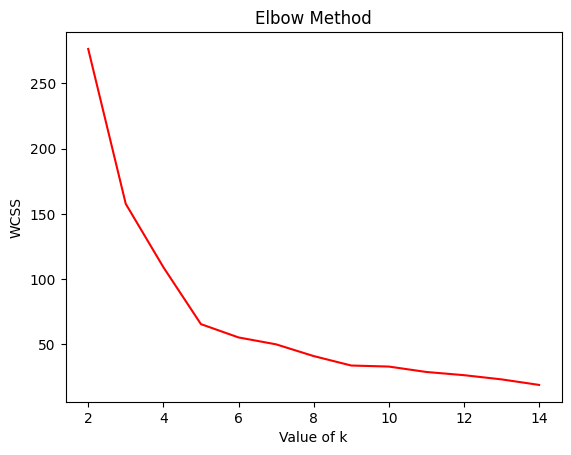

In [15]:
# Elbow Method
import matplotlib.pyplot as plt

plt.title("Elbow Method")
plt.xlabel("Value of k")
plt.ylabel("WCSS")
plt.plot(range(2, 15), wcss, c = 'r')
plt.show()

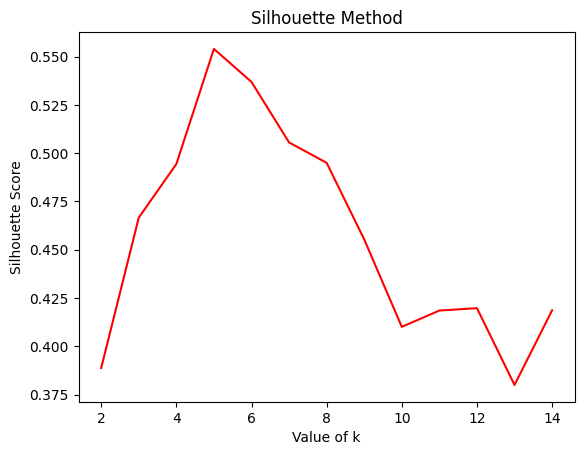

In [16]:
#Silhouette Method
plt.title("Silhouette Method")
plt.xlabel("Value of k")
plt.ylabel("Silhouette Score")
plt.plot(range(2, 15), silScore, c = 'r')
plt.show()

In [17]:
# So the optimal value of k = 5
km = KMeans(n_clusters=5)
prediction = km.fit_predict(x)

centers = km.cluster_centers_
centers

array([[ 0.99158305,  1.23950275],
       [-1.30751869, -1.13696536],
       [ 1.05500302, -1.28443907],
       [-1.32954532,  1.13217788],
       [-0.20091257, -0.02645617]])

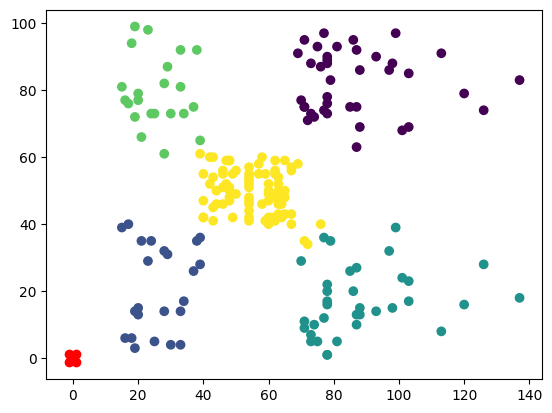

In [18]:
plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"], c = prediction)
plt.scatter(centers[:, 0], centers[:, 1], c = 'r')